#Imports and config

In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)


#Loading full raw dataset

In [3]:

raw_csv = list(DATA_RAW.glob("*.csv"))
assert len(raw_csv) >= 1
df = pd.read_csv(raw_csv[0])
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#Creating 10k chronological batches

In [ ]:
BATCH_SIZE = 10_000
BATCHES = 4
TOTAL_ROWS = BATCH_SIZE * BATCHES

df_sorted = df.sort_values("Time").reset_index(drop=True).iloc[:TOTAL_ROWS].copy()
print(df_sorted.shape)

# Save batches
names_3 = ["batch1_train.csv", "batch2_test.csv", "batch3_stream.csv"]
names_4 = names_3 + ["batch4_stream.csv"]
names = names_4 if BATCHES == 4 else names_3

start = 0
for i, name in enumerate(names, start=1):
    part = df_sorted.iloc[start:start+BATCH_SIZE].copy()
    part.to_csv(DATA_PROCESSED / name, index=False)
    print(name, part.shape, f"fraud_rate={part['Class'].mean():.5f}")
    start += BATCH_SIZE


(40000, 31)
batch1_train.csv (10000, 31) fraud_rate=0.00380
batch2_test.csv (10000, 31) fraud_rate=0.00470
batch3_stream.csv (10000, 31) fraud_rate=0.00090
batch4_stream.csv (10000, 31) fraud_rate=0.00100


#Loading the working batches

In [5]:
train = pd.read_csv(DATA_PROCESSED / "batch1_train.csv")
test  = pd.read_csv(DATA_PROCESSED / "batch2_test.csv")
stream1 = pd.read_csv(DATA_PROCESSED / "batch3_stream.csv")
stream2 = None
if (DATA_PROCESSED / "batch4_stream.csv").exists():
    stream2 = pd.read_csv(DATA_PROCESSED / "batch4_stream.csv")

for name, part in [("train", train), ("test", test), ("stream1", stream1), ("stream2", stream2)]:
    if part is None: continue
    print(f"{name:7s} shape={part.shape}, fraud_rate={part['Class'].mean():.5f}")


train   shape=(10000, 31), fraud_rate=0.00380
test    shape=(10000, 31), fraud_rate=0.00470
stream1 shape=(10000, 31), fraud_rate=0.00090
stream2 shape=(10000, 31), fraud_rate=0.00100


#EDA - Class imbalance & basic stats

In [6]:
def summarize_split(df, label_col="Class"):
    n = len(df)
    pos = df[label_col].sum()
    print(f"Rows={n}, Positives={int(pos)} ({pos/n:.4%})")

print("TRAIN"); summarize_split(train)
print("TEST"); summarize_split(test)
print("STREAM1"); summarize_split(stream1)
if stream2 is not None:
    print("STREAM2"); summarize_split(stream2)

# Amount & Time sanity
train[["Amount","Time"]].describe()


TRAIN
Rows=10000, Positives=38 (0.3800%)
TEST
Rows=10000, Positives=47 (0.4700%)
STREAM1
Rows=10000, Positives=9 (0.0900%)
STREAM2
Rows=10000, Positives=10 (0.1000%)


,Amount,Time
count,10000.000000,10000.000000
mean,63.030188,5966.033400
std,184.486158,4473.403739
min,0.000000,0.000000
25%,5.000000,2072.750000
50%,15.950000,4563.500000
75%,50.960000,10233.250000
max,7712.430000,15012.000000


#Simple Visuals

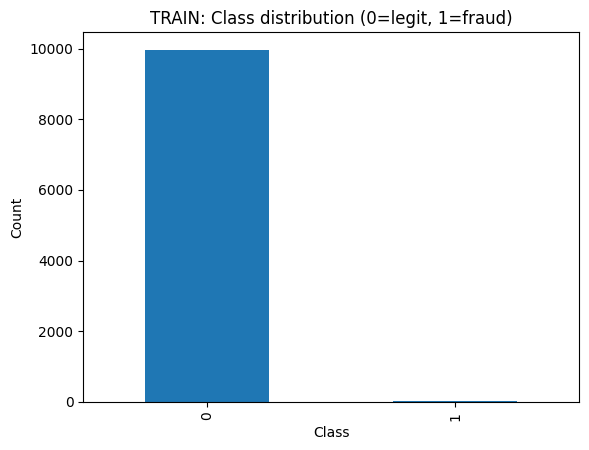

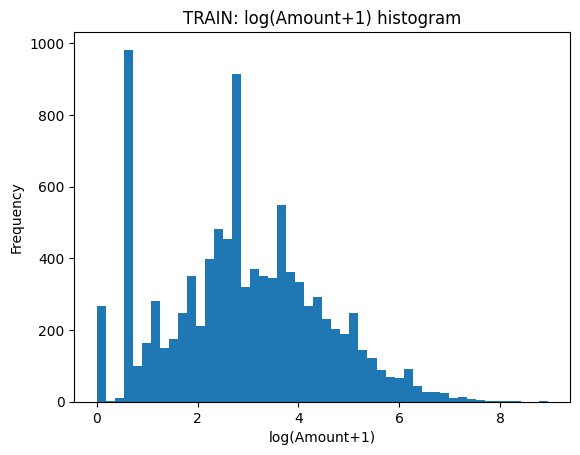

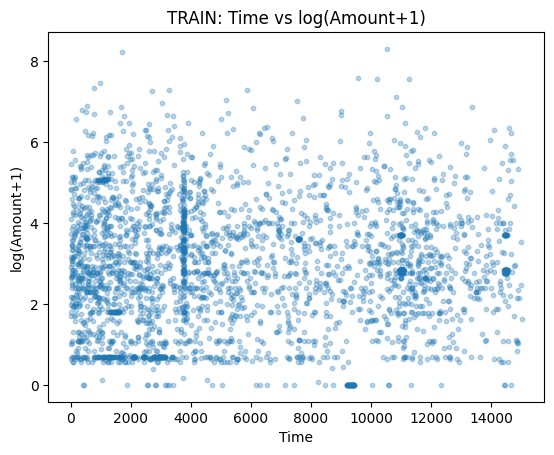

In [7]:
import matplotlib.pyplot as plt

# 1) Imbalance bar
counts = train["Class"].value_counts().sort_index()
plt.figure()
counts.plot(kind="bar")
plt.title("TRAIN: Class distribution (0=legit, 1=fraud)")
plt.xlabel("Class"); plt.ylabel("Count")
plt.show()

# 2) Amount histogram (log1p to see tail)
plt.figure()
plt.hist(np.log1p(train["Amount"]), bins=50)
plt.title("TRAIN: log(Amount+1) histogram")
plt.xlabel("log(Amount+1)"); plt.ylabel("Frequency")
plt.show()

# 3) Time vs Amount scatter (thin sample for speed)
sample = train.sample(min(3000, len(train)), random_state=RANDOM_STATE)
plt.figure()
plt.scatter(sample["Time"], np.log1p(sample["Amount"]), alpha=0.3, s=10)
plt.title("TRAIN: Time vs log(Amount+1)")
plt.xlabel("Time"); plt.ylabel("log(Amount+1)")
plt.show()
